In [175]:
!pip3 install pandas


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [176]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

In [177]:
df = pd.read_excel('classification fraud data.xlsx')

In [178]:
print(df.columns.tolist())

['Policy_ID', 'Policy_Start_Date', 'Policy_Expiry_Date', 'Date_of_Intimation', 'Days_Into_Policy', 'Days_To_Expiry', 'Claim_Amount_Lakh', 'Prior_Claims', 'Online_Channel', 'Fraud_Label']


In [179]:
df.head()
count_fraud = df[df['Fraud_Label'] == 1].shape[0]
print("Number of fraud_label = 1:", count_fraud)

Number of fraud_label = 1: 37


In [180]:
df.columns

Index(['Policy_ID', 'Policy_Start_Date', 'Policy_Expiry_Date',
       'Date_of_Intimation', 'Days_Into_Policy', 'Days_To_Expiry',
       'Claim_Amount_Lakh', 'Prior_Claims', 'Online_Channel', 'Fraud_Label'],
      dtype='object')

In [181]:
df.info()
df.describe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Policy_ID           150 non-null    object        
 1   Policy_Start_Date   150 non-null    datetime64[ns]
 2   Policy_Expiry_Date  150 non-null    datetime64[ns]
 3   Date_of_Intimation  150 non-null    datetime64[ns]
 4   Days_Into_Policy    150 non-null    int64         
 5   Days_To_Expiry      150 non-null    int64         
 6   Claim_Amount_Lakh   150 non-null    float64       
 7   Prior_Claims        150 non-null    int64         
 8   Online_Channel      150 non-null    int64         
 9   Fraud_Label         150 non-null    int64         
dtypes: datetime64[ns](3), float64(1), int64(5), object(1)
memory usage: 11.8+ KB


<bound method NDFrame.describe of     Policy_ID Policy_Start_Date Policy_Expiry_Date Date_of_Intimation  \
0       P2000        2024-04-12         2025-04-12         2025-04-01   
1       P2001        2025-03-11         2026-03-11         2026-02-21   
2       P2002        2024-09-27         2025-09-27         2025-04-04   
3       P2003        2024-04-16         2025-04-16         2025-01-23   
4       P2004        2024-03-12         2025-03-12         2024-07-05   
5       P2005        2024-01-21         2025-01-20         2024-10-05   
6       P2006        2025-09-06         2026-09-06         2026-01-20   
7       P2007        2024-05-01         2025-05-01         2024-12-11   
8       P2008        2025-04-11         2026-04-11         2025-09-29   
9       P2009        2024-08-02         2025-08-02         2025-06-12   
10      P2010        2024-11-26         2025-11-26         2025-03-01   
11      P2011        2025-04-03         2026-04-03         2025-09-29   
12      P2012    

In [182]:

X = df.drop(['Fraud_Label', 'Policy_ID', 'Policy_Start_Date', 'Policy_Expiry_Date', 'Date_of_Intimation'], axis=1)
y = df['Fraud_Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# --- Fraud counts & %
# fraud label is 1 and non-fraud is 0
train_total = len(y_train)
test_total  = len(y_test)

train_fraud = (y_train == 1).sum()
test_fraud  = (y_test == 1).sum()

train_fraud_pct = 100.0 * train_fraud / train_total
test_fraud_pct  = 100.0 * test_fraud / test_total

print("TRAIN:")
print(f"  Total = {train_total:,}")
print(f"  Fraud = {train_fraud:,}")
print(f"  Fraud% = {train_fraud_pct:.2f}%")

print("\nTEST:")
print(f"  Total = {test_total:,}")
print(f"  Fraud = {test_fraud:,}")
print(f"  Fraud% = {test_fraud_pct:.2f}%")







TRAIN:
  Total = 120
  Fraud = 30
  Fraud% = 25.00%

TEST:
  Total = 30
  Fraud = 7
  Fraud% = 23.33%


In [183]:
# KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
knn_trainpred = knn.predict(X_train)
knn_pred = knn.predict(X_test)
print("KNN Train Accuracy:", accuracy_score(y_train, knn_trainpred))
print("KNN Test Accuracy:", accuracy_score(y_test, knn_pred))
# AUC requires probabiility 
knn_proba_test = knn.predict_proba(X_test)[:, 1]  # probability of class 1

knn_auc = roc_auc_score(y_test, knn_proba_test)
print(f"KNN AUC: {knn_auc:.2f}")

KNN Train Accuracy: 0.825
KNN Test Accuracy: 0.6666666666666666
KNN AUC: 0.51


[[86  4]
 [17 13]]


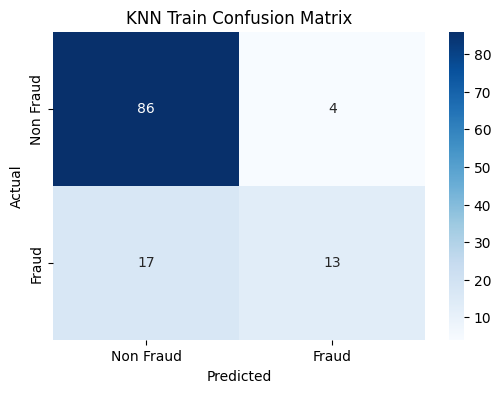

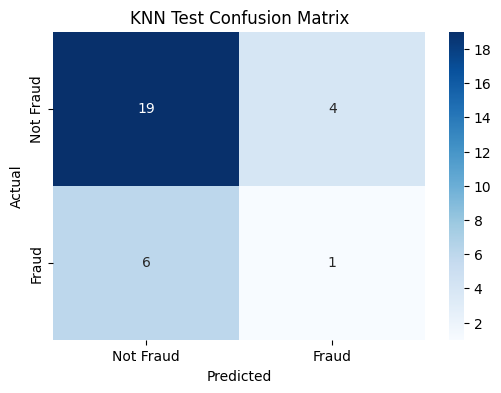

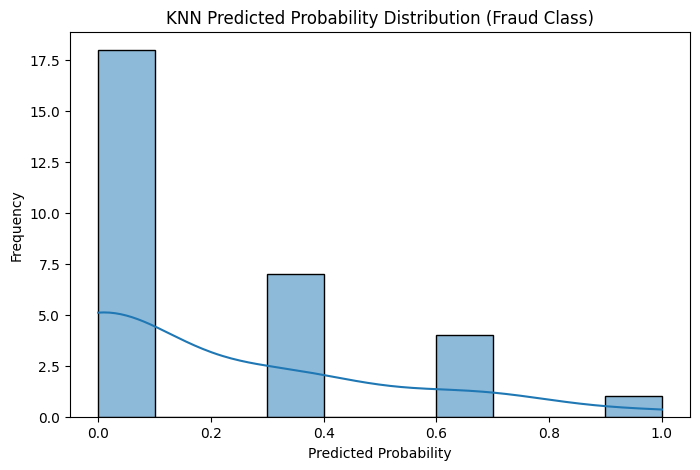

In [184]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

# Confusion matrix for KNN predictions
cm_knn = confusion_matrix(y_train, knn_trainpred)
print(cm_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=['Non Fraud', 'Fraud'], yticklabels=['Non Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Train Confusion Matrix')
plt.show()
cm_knn = confusion_matrix(y_test, knn_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Test Confusion Matrix')
plt.show()


# Visualize KNN prediction probabilities (if available)
if hasattr(knn, "predict_proba"):
    knn_probs = knn.predict_proba(X_test)[:, 1]
    plt.figure(figsize=(8, 5))
    sns.histplot(knn_probs, bins=10, kde=True)
    plt.title("KNN Predicted Probability Distribution (Fraud Class)")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Frequency")
    plt.show()

In [185]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_trainpred = lr.predict(X_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Train Accuracy:", accuracy_score(y_train, lr_trainpred))
print("Logistic Regression Test Accuracy:", accuracy_score(y_test, lr_pred))


#Predicted probabilities
y_prob = lr.predict_proba(X_test)[:, 1] # probability of class 1
print("probability",y_prob)
# AUC requires probabiility 


lr_auc = roc_auc_score(y_test, y_prob)
print("Logistic Regression AUC:", lr_auc)

# finding the best threshold based on F1 score
import numpy as np
from sklearn.metrics import f1_score, precision_score

thresholds = np.arange(0.0, 1.01, 0.01)  # 0.00, 0.01, ..., 1.00
f1_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Best F1 score:", best_f1)
# Final predictions using best threshold
y_pred_best = (y_prob >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best))

Logistic Regression Train Accuracy: 0.75
Logistic Regression Test Accuracy: 0.7333333333333333
probability [0.26686732 0.16051634 0.25136108 0.38566229 0.24771847 0.54711117
 0.27149092 0.1633403  0.24181875 0.25078692 0.16062852 0.24497198
 0.16369362 0.15775715 0.16170614 0.24756766 0.23335866 0.16064158
 0.25095066 0.15997113 0.25313332 0.38909766 0.24239913 0.25202151
 0.5798263  0.1629723  0.1609533  0.55396323 0.25250215 0.16114991]
Logistic Regression AUC: 0.6956521739130435
Best threshold: 0.25
Best F1 score: 0.5
              precision    recall  f1-score   support

           0       0.88      0.65      0.75        23
           1       0.38      0.71      0.50         7

    accuracy                           0.67        30
   macro avg       0.63      0.68      0.62        30
weighted avg       0.77      0.67      0.69        30



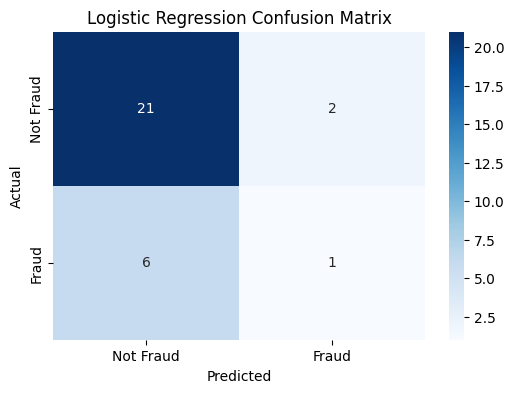

Logistic Regression Recall: 0.14285714285714285
Logistic Regression Precision: 0.3333333333333333


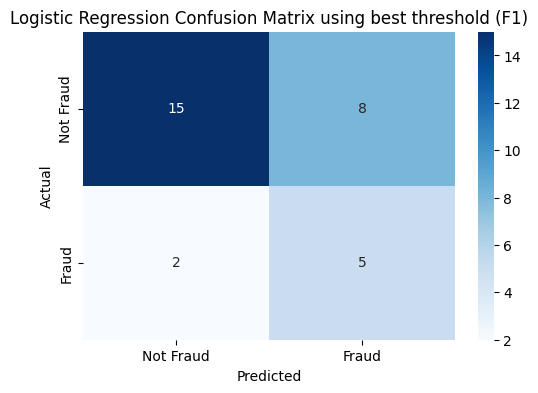

Best threshold (Precision): 0.55
Best Precision score: 0.5


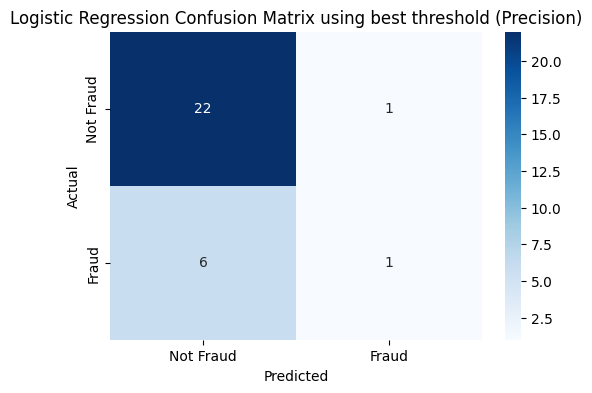

In [186]:
cm_lr = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()
from sklearn.metrics import recall_score,precision_score

# Calculate Precision Recall for logistic regression
lr_recall = recall_score(y_test, lr_pred)
print("Logistic Regression Recall:", lr_recall)
lr_precision = precision_score(y_test, lr_pred)
print("Logistic Regression Precision:", lr_precision)

# Confusion matrix for best threshold based on F1 score
cm_lr_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr_best, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix using best threshold (F1)')
plt.show()

# Best Threshold using Precision Score maximization
# thresholds from 0 to 1 in steps of 0.01
thresholds = np.arange(0.0, 1.01, 0.01)
precision_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    prec = precision_score(y_test, y_pred, zero_division=0)
    precision_scores.append(prec)

# index of best precision
best_idx = np.argmax(precision_scores)

best_threshold = thresholds[best_idx]
best_precision = precision_scores[best_idx]

print("Best threshold (Precision):", best_threshold)
print("Best Precision score:", best_precision)

# Final predictions using this threshold
y_pred_best = (y_prob >= best_threshold).astype(int)

# Confusion matrix for best threshold based on Precision score
cm_lr_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr_best, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix using best threshold (Precision)')
plt.show()


In [187]:
# !pip3 install graphviz

In [188]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


X.head()
print(X.head())
X.head(10).join(y.rename("y"))


   Days_Into_Policy  Days_To_Expiry  Claim_Amount_Lakh  Prior_Claims  \
0               354              11              0.729             1   
1               347              18              0.387             2   
2               189             176              0.518             0   
3               282              83              0.424             2   
4               115             250              0.396             0   

   Online_Channel  
0               1  
1               1  
2               0  
3               1  
4               0  


,Days_Into_Policy,Days_To_Expiry,Claim_Amount_Lakh,Prior_Claims,Online_Channel,y
0,354,11,0.729,1,1,1
1,347,18,0.387,2,1,1
2,189,176,0.518,0,0,1
3,282,83,0.424,2,1,1
4,115,250,0.396,0,0,1
5,258,107,1.085,0,0,1
6,136,229,0.769,0,0,1
7,224,141,0.369,3,1,0
8,171,194,1.124,0,1,0
9,314,51,0.742,0,0,0


one test example: [1]
Decision Tree Test Accuracy: 0.8
Decision Tree Test Recall: 0.14285714285714285
Decision Tree Test Precision: 1.0
Test F1 Score: 0.25
Decision Tree Test AUC: 0.593167701863354
Decision Tree Train Accuracy: 0.8
Decision Tree Train Recall: 0.2
Decision Tree Train Precision: 1.0
Train F1 Score: 0.3333333333333333
Decision Tree Train AUC: 0.742037037037037


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


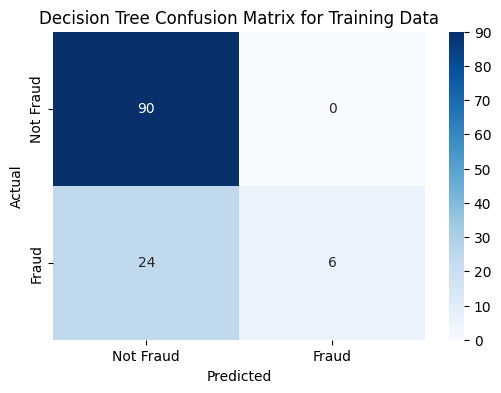

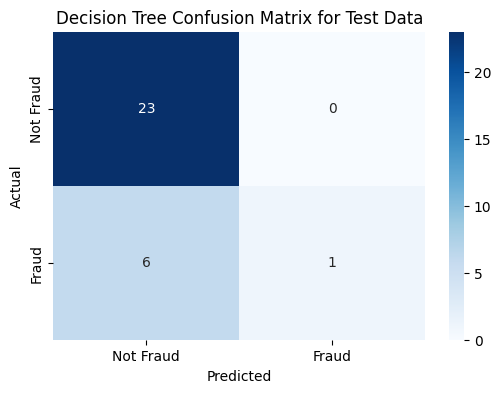

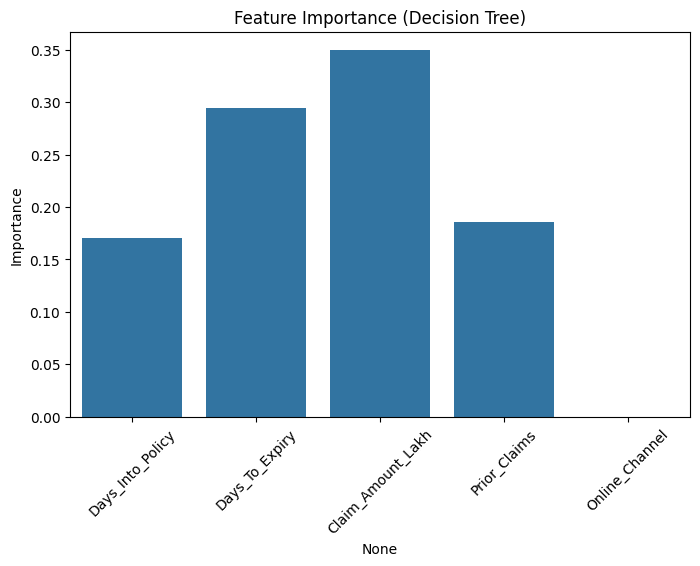

In [189]:
dt = DecisionTreeClassifier(max_depth=3,random_state=42)
dt.fit(X_train, y_train)

# run the model on training data for prediction
dt_train_pred = dt.predict(X_train)

# try one unseen data right here 
dt_pred = dt.predict([[300, 5, .9, 1, 1]])
print("one test example:", dt_pred)

# run the model on test data for prediction
dt_pred = dt.predict(X_test)
# Print Test accuracy, precision, recall, F1
print("Decision Tree Test Accuracy:", accuracy_score(y_test, dt_pred))
dt_recall = recall_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
print("Decision Tree Test Recall:", dt_recall)
print("Decision Tree Test Precision:", dt_precision)
dt_f1 = f1_score(y_test, dt_pred)
print("Test F1 Score:", dt_f1)
# AUC requires probabiility 
dt_proba_test = dt.predict_proba(X_test)[:, 1]  # probability of class 1

dt_auc = roc_auc_score(y_test, dt_proba_test)
print("Decision Tree Test AUC:", dt_auc)

# Print Train accuracy, precision, recall, F1
print("Decision Tree Train Accuracy:", accuracy_score(y_test, dt_pred))
dt_recall = recall_score(y_train, dt_train_pred)
dt_precision = precision_score(y_train, dt_train_pred)
print("Decision Tree Train Recall:", dt_recall)
print("Decision Tree Train Precision:", dt_precision)
dt_f1 = f1_score(y_train, dt_train_pred)
print("Train F1 Score:", dt_f1)
# AUC requires probabiility 
dt_proba_train = dt.predict_proba(X_train)[:, 1]  # probability of class 1

dt_auc = roc_auc_score(y_train, dt_proba_train)
print("Decision Tree Train AUC:", dt_auc)

# Confusion matrix for Decision Tree Training data predictions
cm_dt = confusion_matrix(y_train, dt_train_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix for Training Data')
plt.show()

# Confusion matrix for Decision Tree predictions
cm_dt = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix for Test Data')
plt.show()

# Feature importance using Decision Tree
dt_importance = dt.feature_importances_
plt.figure(figsize=(8, 5))
features = X.columns
sns.barplot(x=features, y=dt_importance)
plt.title("Feature Importance (Decision Tree)")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(20,10))
plot_tree(dt, 
            feature_names=['Days_Into_Policy', 'Days_To_Expiry', 'Claim_Amount_Lakh', 'Prior_Claims', 'Online_Channel'], 
            class_names=[str(c) for c in dt.classes_],
            label="all",
            rounded=True,
            filled=True)
plt.savefig("fraud-predictor.png", dpi=300, bbox_inches='tight')
plt.close()
                                                                        
                                                                       

TRAIN:
 Fraud_Label
0    90
1    30
Name: count, dtype: int64

TEST:
 Fraud_Label
0    23
1     7
Name: count, dtype: int64
Decision Tree Test Accuracy: 0.5333333333333333
Decision Tree Test Recall: 0.8571428571428571
Decision Tree Test Precision: 0.3157894736842105
Test F1 Score: 0.46153846153846156
Decision Tree Test AUC: 0.6583850931677018
 y_test  proba_class_0  proba_class_1  predicted_label  predicted_label_thr
      0       0.700000       0.300000                0                    0
      0       0.426966       0.573034                1                    0
      1       0.426966       0.573034                1                    0
      0       0.250000       0.750000                1                    1
      1       0.426966       0.573034                1                    0
      0       0.250000       0.750000                1                    1
      0       0.700000       0.300000                0                    0
      0       0.426966       0.573034          

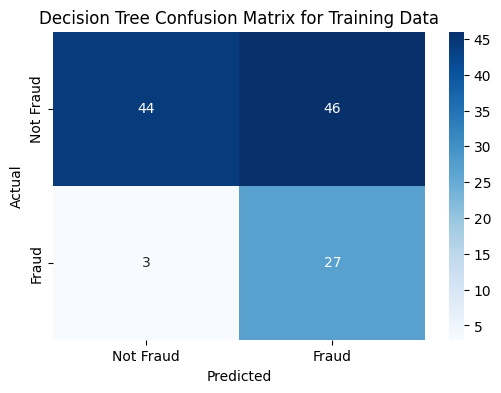

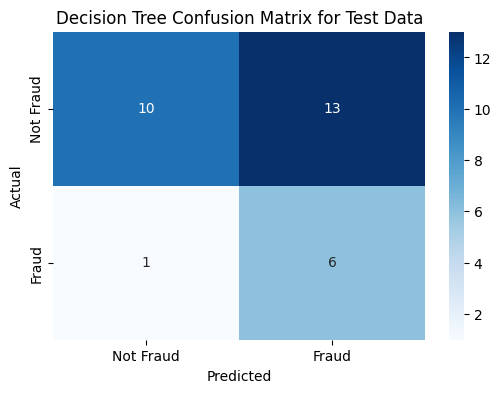

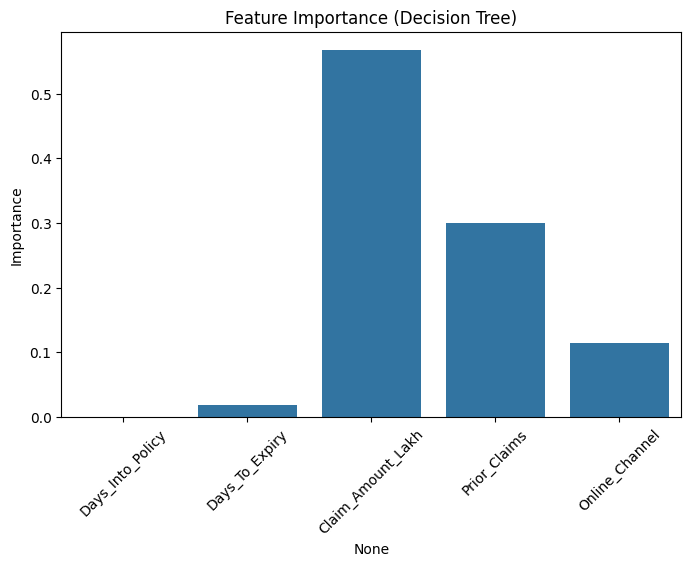

In [190]:
# Compare Decision Tree with different hyperparameters

# X, y assumed to be your features and labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# y_train, y_test are pandas Series
print("TRAIN:\n", y_train.value_counts(dropna=False))
print("\nTEST:\n", y_test.value_counts(dropna=False))


dt = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    class_weight='balanced',
    #class_weight={0: 1, 1: 3},  # Adjusting for class imbalance
    criterion="gini",
    random_state=42
)
dt.fit(X_train, y_train)
# run the model on training data for prediction
dt_train_pred = dt.predict(X_train)

# run the model on test data for prediction
dt_pred = dt.predict(X_test)
# Print Test accuracy, precision, recall, F1
print("Decision Tree Test Accuracy:", accuracy_score(y_test, dt_pred))
dt_recall = recall_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
print("Decision Tree Test Recall:", dt_recall)
print("Decision Tree Test Precision:", dt_precision)
dt_f1 = f1_score(y_test, dt_pred)
print("Test F1 Score:", dt_f1)
# AUC requires probabiility 
dt_proba_test = dt.predict_proba(X_test)[:, 1]  # probability of class 1

dt_auc = roc_auc_score(y_test, dt_proba_test)
print("Decision Tree Test AUC:", dt_auc)


dt_proba_test = dt.predict_proba(X_test)
#threshold = 0.5 based predicted labels
threshold = 0.60
dt_pred_thr = (dt_proba_test[:, 1] >= threshold).astype(int)

out = pd.DataFrame({
    "y_test": y_test.values if hasattr(y_test, "values") else y_test,
    "proba_class_0": dt_proba_test[:, 0],
    "proba_class_1": dt_proba_test[:, 1],
    "predicted_label": dt_pred,
    "predicted_label_thr": dt_pred_thr
})

# Ensure pandas doesn't truncate rows/columns in display
import pandas as pd

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 2000,
    "display.max_colwidth", None
):
    
    print(out.to_string(index=False))

# Print Train accuracy, precision, recall, F1
print("Decision Tree Train Accuracy:", accuracy_score(y_test, dt_pred))
dt_recall = recall_score(y_train, dt_train_pred)
dt_precision = precision_score(y_train, dt_train_pred)
print("Decision Tree Train Recall:", dt_recall)
print("Decision Tree Train Precision:", dt_precision)
dt_f1 = f1_score(y_train, dt_train_pred)
print("Train F1 Score:", dt_f1)
# AUC requires probabiility 
dt_proba_train = dt.predict_proba(X_train)[:, 1]  # probability of class 1

dt_auc = roc_auc_score(y_train, dt_proba_train)
print("Decision Tree Train AUC:", dt_auc)

# Confusion matrix for Decision Tree Training data predictions
cm_dt = confusion_matrix(y_train, dt_train_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix for Training Data')
plt.show()

# Confusion matrix for Decision Tree predictions
cm_dt = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix for Test Data')
plt.show()

# Feature importance using Decision Tree
dt_importance = dt.feature_importances_
plt.figure(figsize=(8, 5))
features = X.columns
sns.barplot(x=features, y=dt_importance)
plt.title("Feature Importance (Decision Tree)")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(20,10))
plot_tree(dt, 
            feature_names=['Days_Into_Policy', 'Days_To_Expiry', 'Claim_Amount_Lakh', 'Prior_Claims', 'Online_Channel'], 
            class_names=[str(c) for c in dt.classes_],
            label="all",
            rounded=True,
            filled=True)
plt.savefig("fraud-predictor-new.png", dpi=300, bbox_inches='tight')
plt.close()

No threshold achieves precision >= 0.60 on validation.
Try lowering target_precision or improving the model/features.


Random Forest Accuracy: 0.7666666666666667
Random Forest Recall: 0.42857142857142855
Random Forest Precision: 0.5


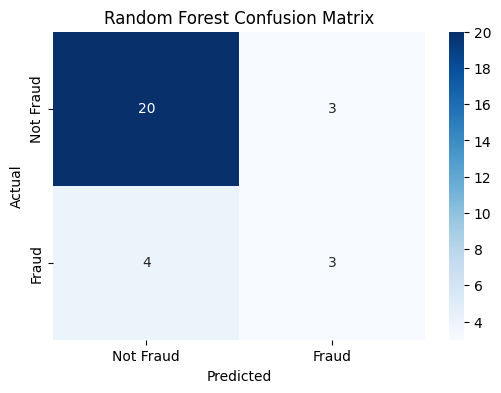

In [192]:
from sklearn.ensemble import RandomForestClassifier
# Random Forest
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
rf_recall = recall_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
print("Random Forest Recall:", rf_recall)
print("Random Forest Precision:", rf_precision)
# Confusion matrix for Random Forest predictions
rf_dt = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(rf_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()